# **Feature Engineering Notebook**

## Objectives

* Encode categorical variables for use in ML pipelines.
* Apply ordinal encoding to ordered features (`experience_level`, `company_size`, `education_required`).
* Apply frequency encoding to high-cardinality columns (`company_location`, `employee_residence`).
* Assess transformed features and their relationship with `salary_usd`.

## Inputs

* `outputs/datasets/cleaned/TrainSet.csv`
* `outputs/datasets/cleaned/TestSet.csv`

## Outputs

* `outputs/datasets/featured/ai_jobs_featured_train.csv`
* `outputs/datasets/featured/ai_jobs_featured_test.csv`
* Insights that inform the pipeline steps in notebook 05 and 06.

---

# Change working directory

In [1]:
import os
current_dir = os.getcwd()
os.chdir(os.path.dirname(current_dir))
print("Working directory:", os.getcwd())

Working directory: c:\Users\chahi\Desktop\vscode-project\the-ai-salary-index


# Load Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

TrainSet = pd.read_csv("outputs/datasets/cleaned/TrainSet.csv")
TestSet = pd.read_csv("outputs/datasets/cleaned/TestSet.csv")
print(f"TrainSet Shape: {TrainSet.shape}")
print(f"TestSet Shape: {TestSet.shape}")
TrainSet.head()

TrainSet Shape: (11760, 14)
TestSet Shape: (2941, 14)


,job_title,salary_usd,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,benefits_score,company_name
0,Machine Learning Engineer,177700,EX,PT,United Kingdom,M,United Kingdom,100,"Kubernetes, SQL, Python",PhD,14,Retail,8.2,Quantum Computing Inc
1,Principal Data Scientist,226559,EX,PT,South Korea,L,Argentina,50,"R, Python, Azure, SQL",PhD,11,Consulting,8.0,Future Systems
2,Research Scientist,109363,SE,CT,Singapore,S,Singapore,100,"Deep Learning, Java, Python",Associate,6,Energy,7.9,Predictive Systems
3,Data Analyst,130819,EX,FT,Finland,M,Finland,100,"Java, R, Mathematics",PhD,15,Telecommunications,8.5,Neural Networks Co
4,NLP Engineer,66333,EN,FL,Australia,M,Australia,100,"SQL, Kubernetes, Hadoop",Bachelor,1,Retail,6.8,Algorithmic Solutions


# Custom Feature Engineering Analysis Function

In [3]:
import scipy.stats as stats
import warnings
from feature_engine import transformation as vt
from feature_engine.outliers import Winsorizer

sns.set(style="whitegrid")
warnings.filterwarnings('ignore')


def FeatureEngineeringAnalysis(df, analysis_type=None):
    """
    Quick feature engineering diagnostic on numerical and categorical variables
    to decide which transformation can better transform the distribution shape.
    """
    check_missing_values(df)
    allowed_types = ['numerical', 'ordinal_encoder', 'outlier_winsorizer']
    check_user_entry_on_analysis_type(analysis_type, allowed_types)
    list_column_transformers = define_list_column_transformers(analysis_type)

    df_feat_eng = pd.DataFrame([])
    for column in df.columns:
        df_feat_eng = pd.concat([df_feat_eng, df[column]], axis=1)
        for method in list_column_transformers:
            df_feat_eng[f"{column}_{method}"] = df[column]

        df_feat_eng, list_applied_transformers = apply_transformers(
            analysis_type, df_feat_eng, column)

        transformer_evaluation(
            column, list_applied_transformers, analysis_type, df_feat_eng)

    return df_feat_eng


def check_user_entry_on_analysis_type(analysis_type, allowed_types):
    if analysis_type is None:
        raise SystemExit(
            f"You should pass analysis_type parameter as one of the following options: {allowed_types}")
    if analysis_type not in allowed_types:
        raise SystemExit(
            f"analysis_type argument should be one of these options: {allowed_types}")


def check_missing_values(df):
    if df.isna().sum().sum() != 0:
        raise SystemExit(
            "There is a missing value in your dataset. Please handle that before getting into feature engineering.")


def define_list_column_transformers(analysis_type):
    if analysis_type == 'numerical':
        list_column_transformers = [
            "log_e", "log_10", "reciprocal", "power", "box_cox", "yeo_johnson"]
    elif analysis_type == 'outlier_winsorizer':
        list_column_transformers = ['iqr']
    return list_column_transformers


def apply_transformers(analysis_type, df_feat_eng, column):
    for col in df_feat_eng.select_dtypes(include='category').columns:
        df_feat_eng[col] = df_feat_eng[col].astype('object')

    if analysis_type == 'numerical':
        df_feat_eng, list_applied_transformers = FeatEngineering_Numerical(
            df_feat_eng, column)
    elif analysis_type == 'outlier_winsorizer':
        df_feat_eng, list_applied_transformers = FeatEngineering_OutlierWinsorizer(
            df_feat_eng, column)
    elif analysis_type == 'ordinal_encoder':
        df_feat_eng, list_applied_transformers = FeatEngineering_CategoricalEncoder(
            df_feat_eng, column)
    return df_feat_eng, list_applied_transformers


def transformer_evaluation(column, list_applied_transformers, analysis_type, df_feat_eng):
    print(f"* Variable Analyzed: {column}")
    print(f"* Applied transformation: {list_applied_transformers} \n")
    for col in [column] + list_applied_transformers:
        if analysis_type != 'ordinal_encoder':
            DiagnosticPlots_Numerical(df_feat_eng, col)
        else:
            if col == column:
                DiagnosticPlots_Categories(df_feat_eng, col)
            else:
                DiagnosticPlots_Numerical(df_feat_eng, col)
        print("\n")


def DiagnosticPlots_Numerical(df, variable):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    sns.histplot(data=df, x=variable, kde=True, element="step", ax=axes[0])
    stats.probplot(df[variable], dist="norm", plot=axes[1])
    sns.boxplot(x=df[variable], ax=axes[2])
    axes[0].set_title('Histogram')
    axes[1].set_title('QQ Plot')
    axes[2].set_title('Boxplot')
    fig.suptitle(f"{variable}", fontsize=30, y=1.05)
    plt.tight_layout()
    plt.show()


def FeatEngineering_OutlierWinsorizer(df_feat_eng, column):
    list_methods_worked = []
    try:
        disc = Winsorizer(
            capping_method='iqr', tail='both', fold=1.5, variables=[f"{column}_iqr"])
        df_feat_eng = disc.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_iqr")
    except Exception:
        df_feat_eng.drop([f"{column}_iqr"], axis=1, inplace=True)
    return df_feat_eng, list_methods_worked


def FeatEngineering_Numerical(df_feat_eng, column):
    list_methods_worked = []

    try:
        lt = vt.LogTransformer(variables=[f"{column}_log_e"])
        df_feat_eng = lt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_log_e")
    except Exception:
        df_feat_eng.drop([f"{column}_log_e"], axis=1, inplace=True)

    try:
        lt = vt.LogTransformer(variables=[f"{column}_log_10"], base='10')
        df_feat_eng = lt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_log_10")
    except Exception:
        df_feat_eng.drop([f"{column}_log_10"], axis=1, inplace=True)

    try:
        rt = vt.ReciprocalTransformer(variables=[f"{column}_reciprocal"])
        df_feat_eng = rt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_reciprocal")
    except Exception:
        df_feat_eng.drop([f"{column}_reciprocal"], axis=1, inplace=True)

    try:
        pt = vt.PowerTransformer(variables=[f"{column}_power"])
        df_feat_eng = pt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_power")
    except Exception:
        df_feat_eng.drop([f"{column}_power"], axis=1, inplace=True)

    try:
        bct = vt.BoxCoxTransformer(variables=[f"{column}_box_cox"])
        df_feat_eng = bct.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_box_cox")
    except Exception:
        df_feat_eng.drop([f"{column}_box_cox"], axis=1, inplace=True)

    try:
        yjt = vt.YeoJohnsonTransformer(variables=[f"{column}_yeo_johnson"])
        df_feat_eng = yjt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_yeo_johnson")
    except Exception:
        df_feat_eng.drop([f"{column}_yeo_johnson"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked

# Numerical Transformation Investigation

Before encoding categorical features, we investigate whether numerical features benefit from mathematical transformations to reduce skewness.

Skewed features can hurt linear models and distance-based algorithms. XGBoost is generally robust to skewness, but normalising distributions can still improve performance and interpretability.

**Approach:** We use the `FeatureEngineeringAnalysis` custom function to systematically test 6 transformations (log_e, log_10, reciprocal, power, box_cox, yeo_johnson) on each numerical feature and produce diagnostic plots (histogram, QQ plot, boxplot).

**Note:** `remote_ratio` is excluded from this investigation as it is a categorical variable (0, 50, 100) despite being stored as a numeric dtype.

Numerical features to investigate: ['years_experience', 'benefits_score']
* Variable Analyzed: years_experience
* Applied transformation: ['years_experience_power', 'years_experience_yeo_johnson'] 



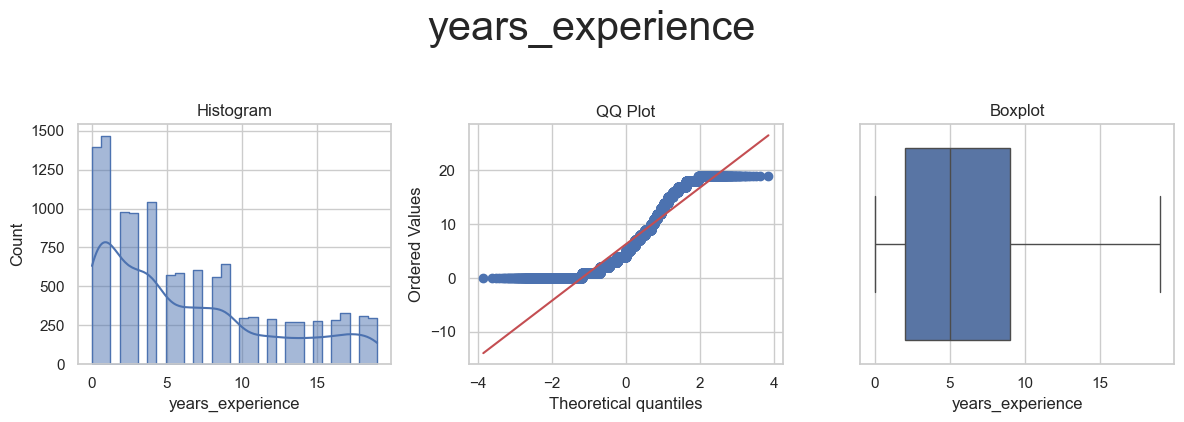

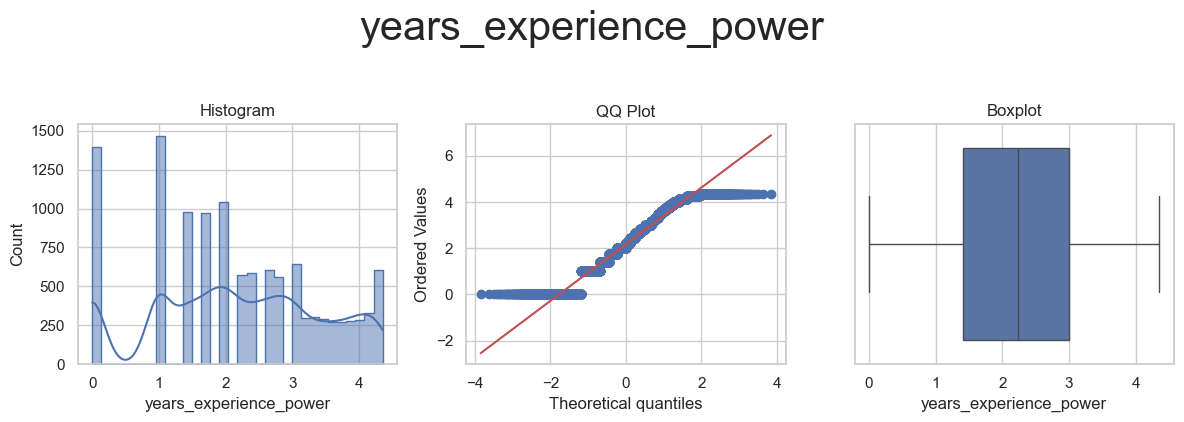

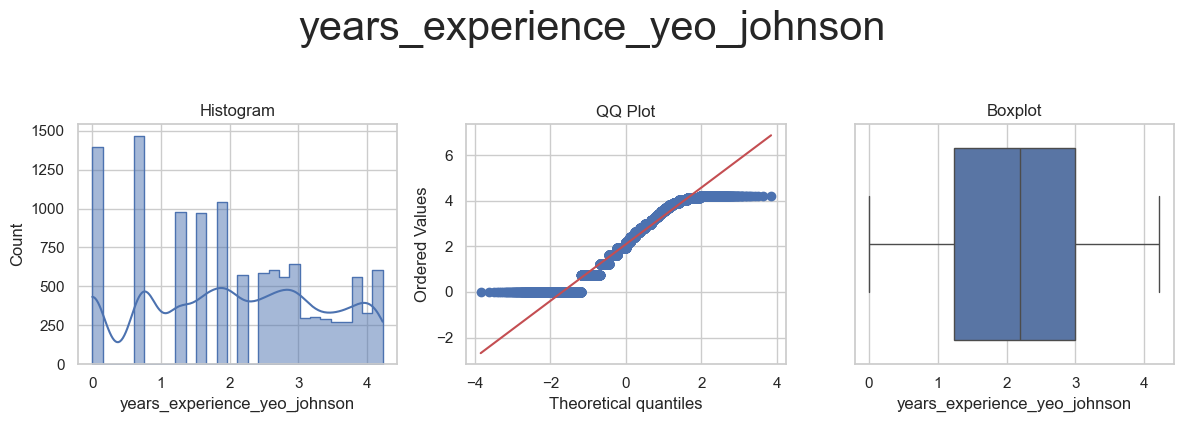



* Variable Analyzed: benefits_score
* Applied transformation: ['benefits_score_log_e', 'benefits_score_log_10', 'benefits_score_reciprocal', 'benefits_score_power', 'benefits_score_box_cox', 'benefits_score_yeo_johnson'] 



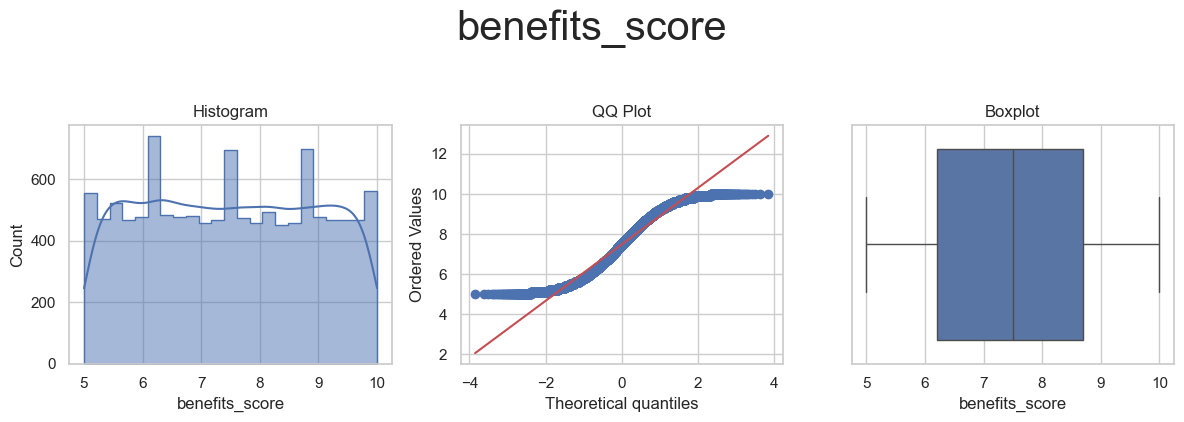

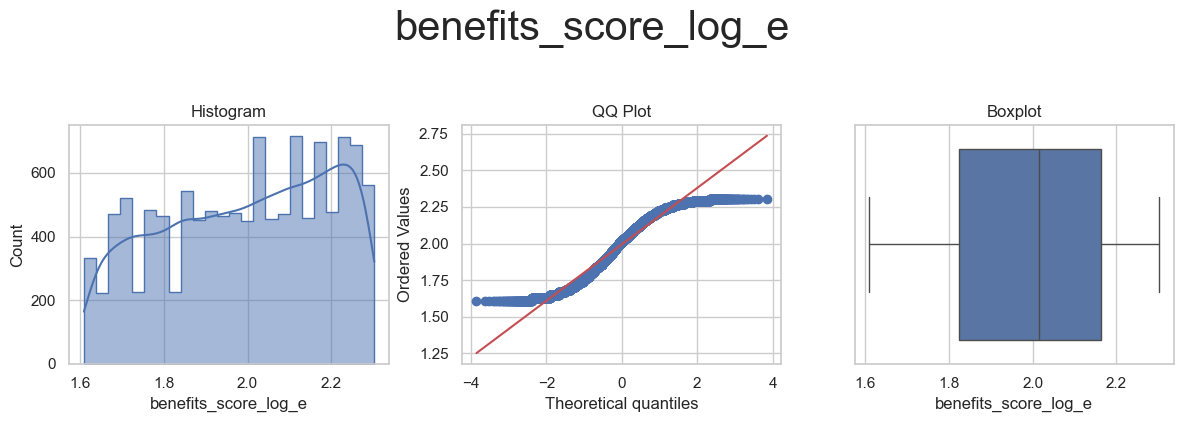

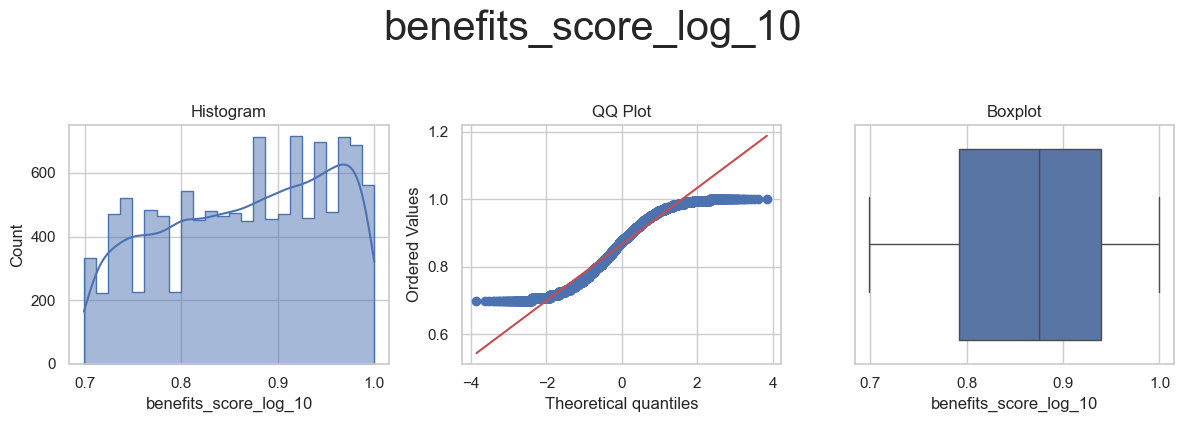

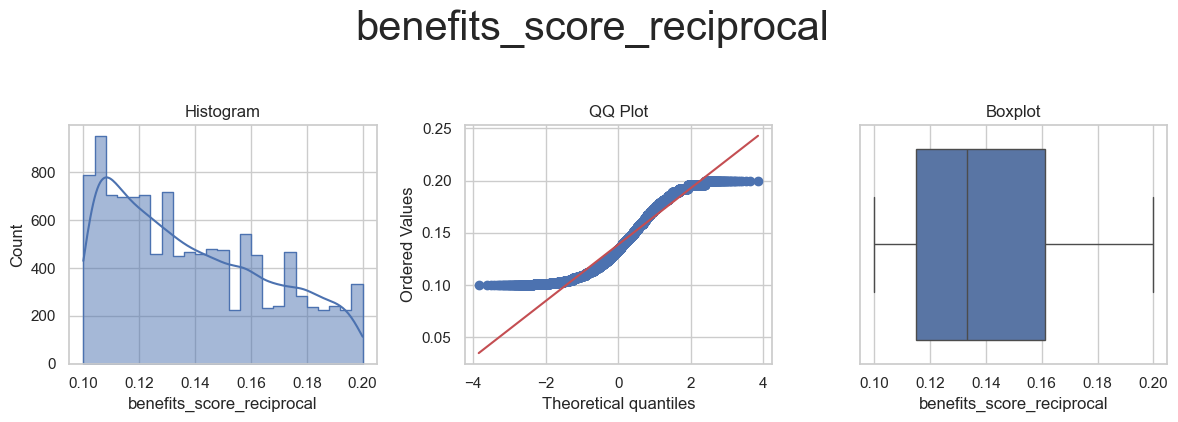

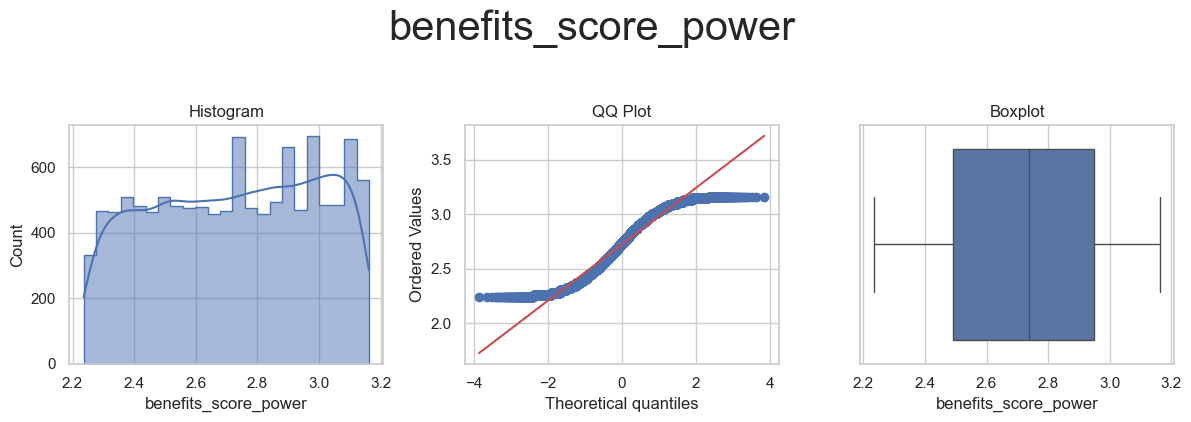

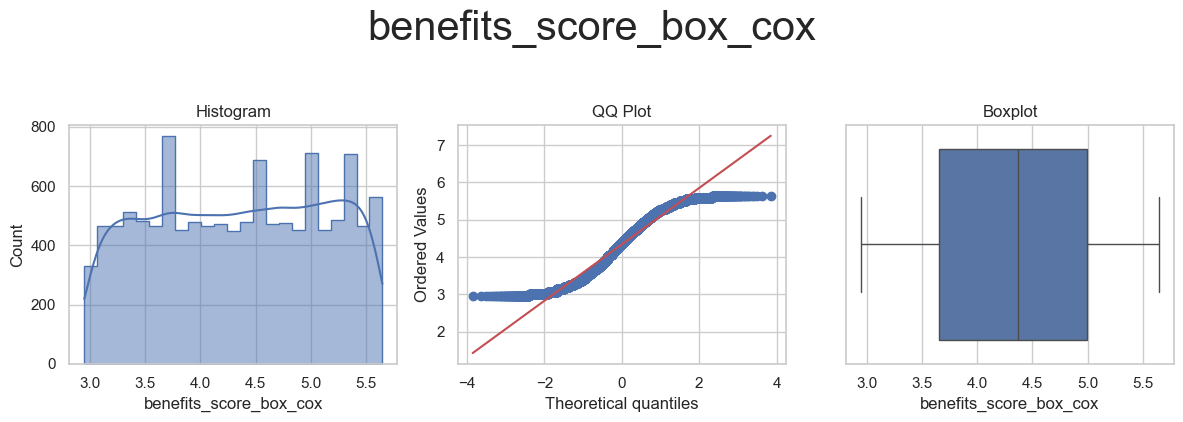

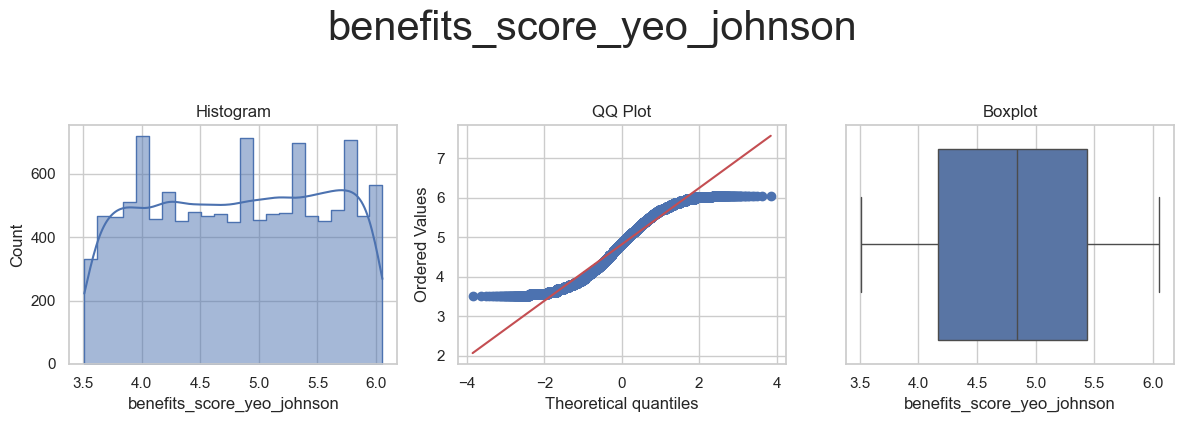

In [4]:
numerical_cols = TrainSet.select_dtypes(include='number').columns.tolist()
numerical_cols = [c for c in numerical_cols if c not in ['salary_usd', 'remote_ratio']]
print("Numerical features to investigate:", numerical_cols)

df_numerical_feat_eng = FeatureEngineeringAnalysis(
    df=TrainSet[numerical_cols].copy(), analysis_type='numerical'
)

## Outlier Winsorizer Investigation

We also assess whether capping outliers via IQR winsorization improves feature distributions.

* Variable Analyzed: years_experience
* Applied transformation: ['years_experience_iqr'] 



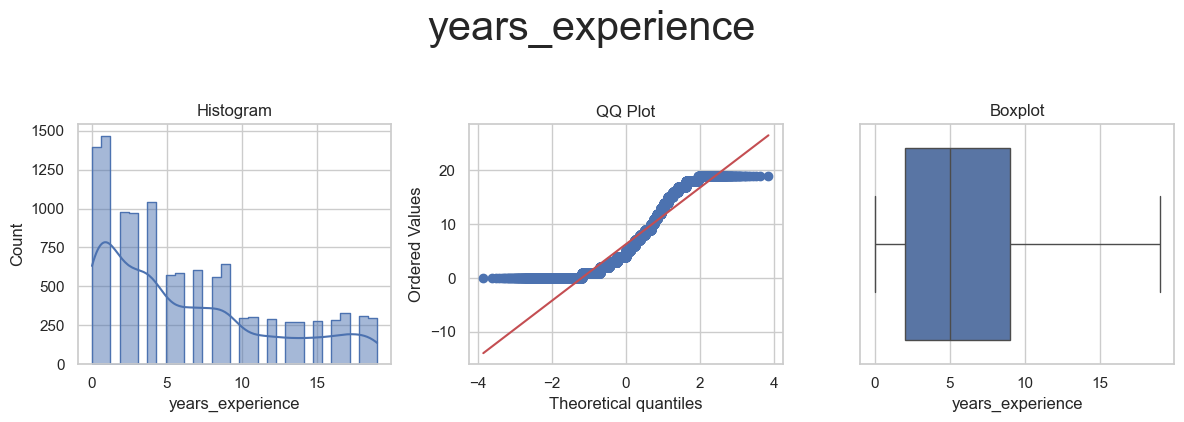

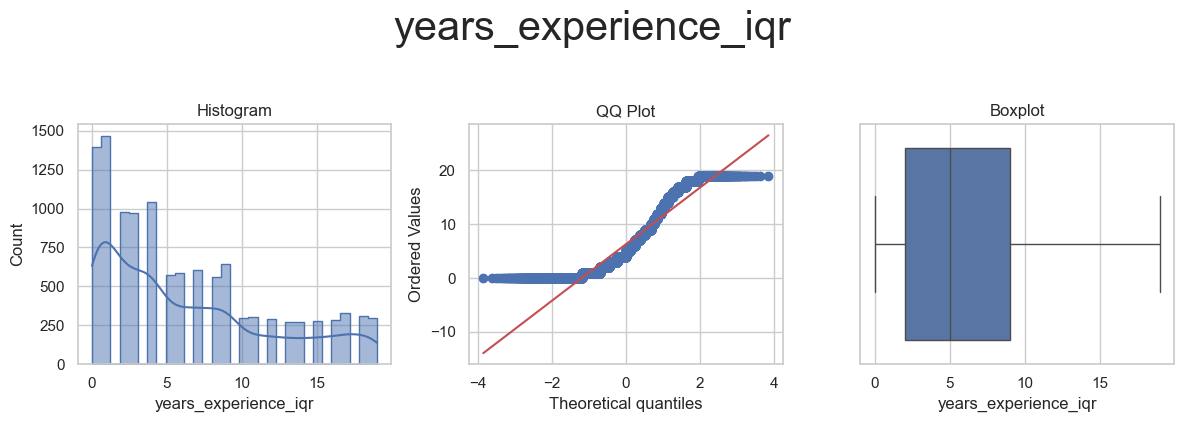



* Variable Analyzed: benefits_score
* Applied transformation: ['benefits_score_iqr'] 



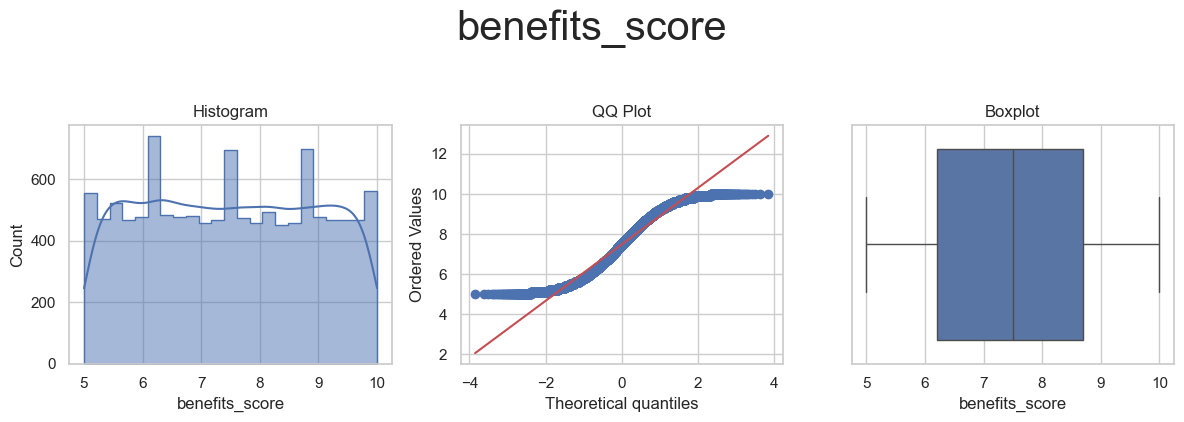

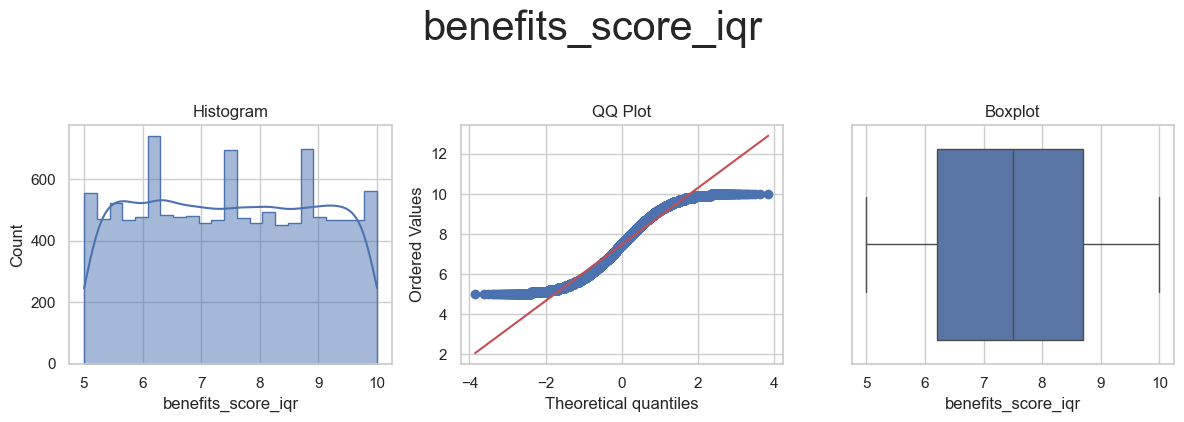

In [5]:
df_outlier_feat_eng = FeatureEngineeringAnalysis(
    df=TrainSet[numerical_cols].copy(), analysis_type='outlier_winsorizer'
)

## Transformation Decision

Based on the `FeatureEngineeringAnalysis` diagnostic plots above (histogram, QQ plot, boxplot for each transformation):

| Feature | Decision | Rationale |
|---|---|---|
| `years_experience` | No transformation | Approximately symmetric; no transformation substantially improves normality |
| `benefits_score` | No transformation | Approximately symmetric |
| Outlier winsorization | Not applied | Boxplots show no extreme outliers requiring capping |

**Conclusion:** No numerical transformations or outlier winsorization are applied in this dataset. The encoding steps below focus on categorical feature transformation.

## Ordinal Encoding — experience_level

In [6]:
exp_map = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
TrainSet['experience_level_enc'] = TrainSet['experience_level'].map(exp_map)
TestSet['experience_level_enc'] = TestSet['experience_level'].map(exp_map)
print(TrainSet[['experience_level', 'experience_level_enc']].drop_duplicates().sort_values('experience_level_enc'))

  experience_level  experience_level_enc
4               EN                     0
6               MI                     1
2               SE                     2
0               EX                     3


## Ordinal Encoding — company_size

In [7]:
size_map = {'S': 0, 'M': 1, 'L': 2}
TrainSet['company_size_enc'] = TrainSet['company_size'].map(size_map)
TestSet['company_size_enc'] = TestSet['company_size'].map(size_map)
print(TrainSet[['company_size', 'company_size_enc']].drop_duplicates().sort_values('company_size_enc'))

  company_size  company_size_enc
2            S                 0
0            M                 1
1            L                 2


## Ordinal Encoding — education_required

In [8]:
print("Unique values:", TrainSet['education_required'].unique())
edu_map = {
    'Associate': 0,
    'Bachelor': 1,
    'Master': 2,
    'PhD': 3
}
TrainSet['education_required_enc'] = TrainSet['education_required'].map(edu_map)
TestSet['education_required_enc'] = TestSet['education_required'].map(edu_map)
print("NaNs in TrainSet:", TrainSet['education_required_enc'].isna().sum())
print("NaNs in TestSet:", TestSet['education_required_enc'].isna().sum())
print(TrainSet[['education_required', 'education_required_enc']].drop_duplicates().sort_values('education_required_enc'))

Unique values: ['PhD' 'Associate' 'Bachelor' 'Master']
NaNs in TrainSet: 0
NaNs in TestSet: 0
  education_required  education_required_enc
2          Associate                       0
4           Bachelor                       1
9             Master                       2
0                PhD                       3


## One-Hot Encoding — employment_type

In [9]:
TrainSet = pd.get_dummies(TrainSet, columns=['employment_type'], drop_first=True, dtype=int)
TestSet = pd.get_dummies(TestSet, columns=['employment_type'], drop_first=True, dtype=int)

# Align TestSet columns to TrainSet in case of missing categories
TestSet = TestSet.reindex(columns=TrainSet.columns, fill_value=0)

print(TrainSet.filter(like='employment_type').head())

   employment_type_FL  employment_type_FT  employment_type_PT
0                   0                   0                   1
1                   0                   0                   1
2                   0                   0                   0
3                   0                   1                   0
4                   1                   0                   0


## Frequency Encoding — company_location & employee_residence

In [10]:
for col in ['company_location', 'employee_residence']:
    # Compute frequency map from TrainSet only — apply same map to TestSet
    freq_map = TrainSet[col].value_counts(normalize=True)
    TrainSet[f'{col}_freq'] = TrainSet[col].map(freq_map)
    TestSet[f'{col}_freq'] = TestSet[col].map(freq_map)
    print(f"{col}_freq sample:")
    print(TrainSet[[col, f'{col}_freq']].drop_duplicates().head(5))
    print()

company_location_freq sample:
  company_location  company_location_freq
0   United Kingdom               0.052636
1      South Korea               0.053061
2        Singapore               0.052041
3          Finland               0.048554
4        Australia               0.047449

employee_residence_freq sample:
  employee_residence  employee_residence_freq
0     United Kingdom                 0.042007
1          Argentina                 0.006888
2          Singapore                 0.041752
3            Finland                 0.037925
4          Australia                 0.039966



## Assess Transformed Features

In [11]:
num_cols = TrainSet.select_dtypes(include='number').columns.tolist()
corr = TrainSet[num_cols].corr()['salary_usd'].drop('salary_usd').sort_values(key=abs, ascending=False)
print("Correlation with salary_usd (post-feature engineering):")
print(corr.head(15))

Correlation with salary_usd (post-feature engineering):
experience_level_enc       0.761041
years_experience           0.742954
company_size_enc           0.169485
company_location_freq      0.156872
employment_type_FL         0.025722
education_required_enc    -0.013426
remote_ratio               0.004944
benefits_score            -0.004444
employee_residence_freq    0.003618
employment_type_PT        -0.002572
employment_type_FT        -0.000056
Name: salary_usd, dtype: float64


## Smart Correlated Selection

We use `SmartCorrelatedSelection` to identify groups of features that are highly correlated with each other (Spearman > 0.6). This is an **investigation step only** — no features are dropped here. The decision on whether to remove correlated features will be made in the modeling notebook, based on model performance.

In [12]:
from feature_engine.selection import SmartCorrelatedSelection

# Select only numeric/encoded columns (exclude original categorical text columns and target)
numeric_features = TrainSet.select_dtypes(include='number').columns.tolist()
numeric_features = [c for c in numeric_features if c != 'salary_usd']

corr_sel = SmartCorrelatedSelection(
    variables=numeric_features, method="spearman", threshold=0.6, selection_method="variance"
)

corr_sel.fit_transform(TrainSet[numeric_features])

print("Correlated feature groups found:")
print(corr_sel.correlated_feature_sets_)
print("\nFeatures to drop:")
print(corr_sel.features_to_drop_)

Correlated feature groups found:
[{'years_experience', 'experience_level_enc'}]

Features to drop:
['experience_level_enc']


# Save Featured Dataset

In [13]:
os.makedirs('outputs/datasets/featured', exist_ok=True)
TrainSet.to_csv('outputs/datasets/featured/ai_jobs_featured_train.csv', index=False)
TestSet.to_csv('outputs/datasets/featured/ai_jobs_featured_test.csv', index=False)
print(f"Saved featured dataset. Shape: {TrainSet.shape}")
TrainSet.head()

Saved featured dataset. Shape: (11760, 21)


,job_title,salary_usd,experience_level,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,...,benefits_score,company_name,experience_level_enc,company_size_enc,education_required_enc,employment_type_FL,employment_type_FT,employment_type_PT,company_location_freq,employee_residence_freq
0,Machine Learning Engineer,177700,EX,United Kingdom,M,United Kingdom,100,"Kubernetes, SQL, Python",PhD,14,...,8.2,Quantum Computing Inc,3,1,3,0,0,1,0.052636,0.042007
1,Principal Data Scientist,226559,EX,South Korea,L,Argentina,50,"R, Python, Azure, SQL",PhD,11,...,8.0,Future Systems,3,2,3,0,0,1,0.053061,0.006888
2,Research Scientist,109363,SE,Singapore,S,Singapore,100,"Deep Learning, Java, Python",Associate,6,...,7.9,Predictive Systems,2,0,0,0,0,0,0.052041,0.041752
3,Data Analyst,130819,EX,Finland,M,Finland,100,"Java, R, Mathematics",PhD,15,...,8.5,Neural Networks Co,3,1,3,0,1,0,0.048554,0.037925
4,NLP Engineer,66333,EN,Australia,M,Australia,100,"SQL, Kubernetes, Hadoop",Bachelor,1,...,6.8,Algorithmic Solutions,0,1,1,1,0,0,0.047449,0.039966


---

# Conclusions and Next Steps

* Ordinal encoding applied to `experience_level`, `company_size`, `education_required`.
* One-hot encoding applied to `employment_type`.
* Frequency encoding applied to `company_location` and `employee_residence`.
* Feature-engineered dataset saved.

Next step: **05 - ModelingEvaluation - PredictSalary** — build and evaluate a regression model.